# Assignment 2
### Understanding Uncertainty
### Due 9/12

1. 'State Bottle Retail' is the price at which the bottle is sold, while 'State Bottle Cost' is the price the state pays for a bottle.
- How do you define the most profitable item? Why? Explain your thinking.
- Use `.groupby` calculations to determine the most profitable liquors sold in Iowa.
- Make a plot of the top liquors

In [2]:
import os 
import pandas as pd
import numpy as np
iowa = pd.read_csv('iowa.csv')

<Axes: xlabel='Item Description'>

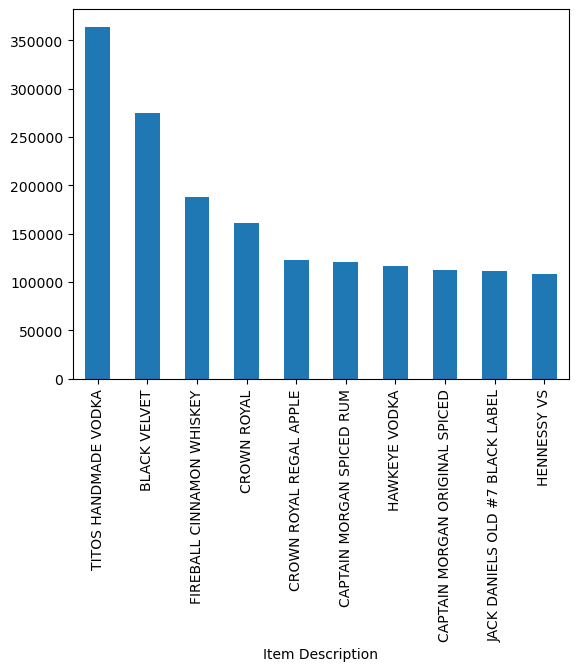

In [3]:
#I would subtract the Price the States pays for a bottle from the retail price and then multiply that by the number of bottles sold. 
# This will give us how much money is made on each bottle sold or like the per unit profit
iowa["Profit"]=iowa["State Bottle Retail"]-iowa["State Bottle Cost"]   
iowa["Most_Profitable"] = iowa["Profit"] * iowa["Bottles Sold"]

bottle_profit = (
    iowa.groupby("Item Description")["Most_Profitable"]
    .sum()
    .sort_values( ascending=False)
)

bottle_profit.head(10).plot.bar() #doing head 10 because there were SOO many values so this will show the top 10 


2. This question is to further explore broadcasting in NumPy.

- In the first code chunk below, there are two vectors, $x$ and $y$. What happens when you try to subtract them?
- Instead, try `x.reshape(-1,1)-y.reshape(1,-1)`. What do you get?
- Try `x.reshape(1,-1)-y.reshape(-1,1)`. Compare the results to your previous answer.
- Write two double for-loops to replicate the results of the previous two answers. 
- Clearly explain how `x.reshape(1,-1)` and `x.reshape(-1,1)` change $x$

In [4]:
import numpy as np

x = np.array([1,3,5])
y = np.array([2,5])


In [5]:
x.reshape(-1,1) - y.reshape(1,-1)

array([[-1, -4],
       [ 1, -2],
       [ 3,  0]])

In [6]:
y.reshape(1,-1) - x.reshape(-1,1)

array([[ 1,  4],
       [-1,  2],
       [-3,  0]])

In [7]:
new_loop = np.zeros((len(x),len(y)))
for i in range(len(x)):
    for j in range(len(y)):
        new_loop[i][j] = y[j] - x[i]

new_loop

array([[ 1.,  4.],
       [-1.,  2.],
       [-3.,  0.]])

In [8]:
new_loop_2 = np.zeros((len(x), len(y)))
for i in range(len(x)):       
    for j in range(len(y)):  
        new_loop_2[i,j] = y[j] - x[i] 

new_loop_2

array([[ 1.,  4.],
       [-1.,  2.],
       [-3.,  0.]])

3. The indicator function $\mathbb{I}\{ x \le z \}$ takes the value 0 if $x>z$ and 1 if $x \le z$ is true, or
$$
\mathbb{I}\{x \le z\} = \begin{cases}
0, &x > z \\
1, &x \le z
\end{cases}
$$

- For $x = 3$, plot the indicator function for any $z$
- Explain how $ 1- \mathbb{I}\{ x \le z \} = \mathbb{I}\{ x > z \}$. Drawing a plot might help, or looking at the definition given above.
- The code below generates a random sample for different numbers of observations, $N = 3, 30, 300, 3000 $. Write a function to compute the ECDF curve for each sample, and plot your results.
- Describe in your own words what happens to the ECDF qualitatively as the sample size $N$ increases

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

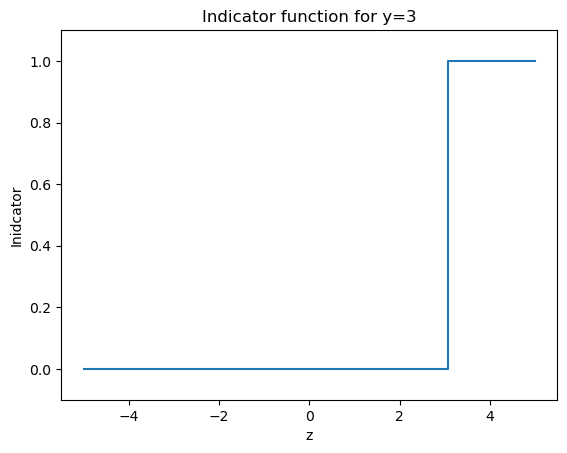

In [10]:
grid = np.linspace(-5, 5, 100)
y = 3

indicator = (y <= grid).astype(int)

plt.step(grid, indicator, where='post') 
plt.xlabel ("z")
plt.ylabel("Inidcator")
plt.title("Indicator function for y=3") 
plt.ylim(-0.1,1.1)
plt.show()

The equation has to be true because there can only be a set input 0 or 1 and the equation makes it so that the 0 or 1 always equal each other on each side. 

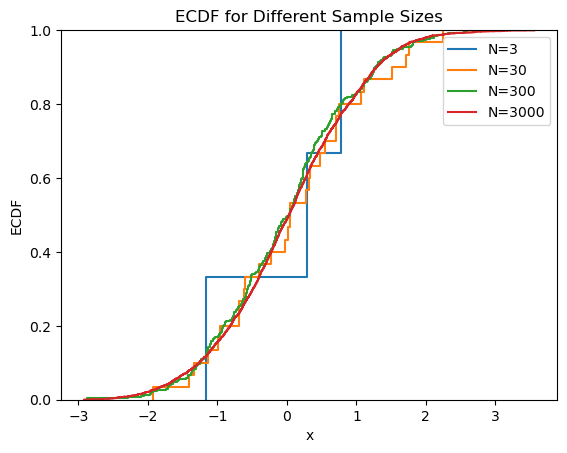

In [12]:
rng = np.random.default_rng(100)

for N in (3,30,300,3000):
    X = rng. normal(0,1,N)
# ECDF plot goes here:
    sns. ecdfplot(X, label=f"N={N}" )
    plt.xlabel ("x")
    plt.ylabel ("ECDF")
    plt.title(f"ECDF for Different Sample Sizes")
    plt. legend ( )

Here the estimate of a distrubution are becoming incresingly more accurate and the sample size also increases. So like its just the idea that a larger sample size = good. 

4. A **quantile** generalizes the concept of the median so that instead of 50% of the mass below and 50% above, the $q$-quantile is the value for which $q$ proportion of the data are below that value and $(1-q)$ proportion of the data are above that value. This is a concept of **order**.

- Write a function that computes any quantile without using Numpy's `np.quantile`
- Write a function that computes the **Interquartile Range (IQR)** -- the .25 quantile and the .75 quantile, which brackets 50% of the data -- and the **whiskers**: $\pm 1.5 \times \text{IQR}$ from the edges of the IQR
- Write a function that computes a five-number summary and values for a boxplot: the minimum, the .25 quantile, the median, the .75 quantile, and the maximum, and the whiskers
- Anything outside the whiskers is an **outlier**; write a function that returns a Boolean vector indicating if the observations are outliers.
- For a numeric variable of your choice from one of the datasets, apply your functions from above, and compare your answers with `sns.boxplot` and `df.describe`. 

In [18]:
def my_quantile(data, q):
    """Compute the q-quantile of data without np.quantile."""
    data = np.sort(data)
    n = len(data)
    pos = q*(n - 1)
    lower = int(np. floor (pos) )
    upper = int(np. ceil (pos) )
    if lower == upper:
        return data[lower]
    else:
        return data[lower] + (pos - lower) * (data[upper] - data[lower])

In [29]:
def my_iqr(data) :
    q1 = my_quantile(data,0.25)
    q3 = my_quantile(data,0.75)
    return q3 - q1, q1, 93

def my_whiskers(data) :
    iqr, q1, q3 = my_iqr(data)
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr
    return lower_whisker, upper_whisker

In [22]:
def five_number_summary(data) :
    data = np. sort(data)
    q1 = my_quantile(data, 0.25)
    q2 = my_quantile(data, 0.50)
    q3 = my_quantile(data, 0.75)
    iqr= my_iqr(data)
    whiskers = my_whiskers(data)
    
    
    return {
        "min": data[0],
        "Q1": q1,
        "median": q2,
        "Q3": q3,
        "max": data[-1,],
        "IQR": iqr,
        "whiskers": whiskers

}   

In [27]:
def detect_outliers(data):
    lower, upper = my_whiskers(data)
    return (data < lower) | (data > upper)

Custom functions:
{'min': np.float64(3.07), 'Q1': np.float64(13.3475), 'median': np.float64(17.795), 'Q3': np.float64(24.127499999999998), 'max': np.float64(50.81), 'IQR': (np.float64(10.779999999999998), np.float64(13.3475), 93), 'whiskers': (np.float64(-2.8224999999999945), np.float64(109.16999999999999))}

Pandas describe:
count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


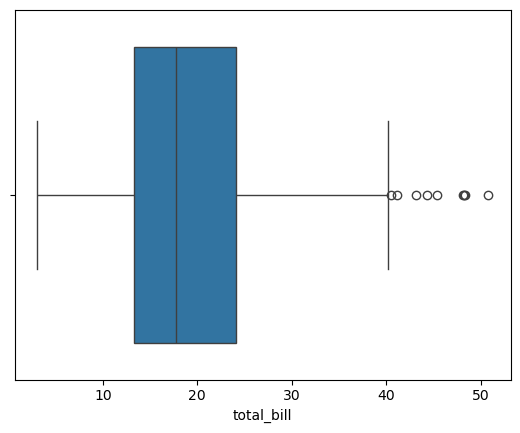

In [30]:
df = sns.load_dataset("tips") 
x = df["total_bill"].values

print("Custom functions:")
print(five_number_summary(x))

print("\nPandas describe:")
print(df["total_bill"] .describe())

sns.boxplot(x=df ["total_bill"])
plt.show()

5. The kernel density estimator captures the concentration of the data around various points, and is defined as
$$
\hat{f}_{N,h}(z) = \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k \left( \frac{x_i - z}{h}\right)
$$
where $h$ is the bandwidth and $k()$ is one of the kernel functions from the class materials (Gaussian, Epanechnikov, uniform, triangular).

- Write a function that takes the bandwidth $h$ as given, and computes and plots $\hat{f}_{N,h}(z)$, for the kernels listed in the slides
- Write a function that computes the plug-in bandwidth
- Use your functions to analyze some numeric variables from a dataset of your choice, using a variety of bandwidths
- Compare bandwidths that are greater or less than the plug-in value with the results for the plug-in value. When does the KDE appear to be overfitting? Underfitting?